Sleeve Bearing Experiment

* **Action:** Following the re-alignment experiment mentioned above, we conducted a secondary test. This involved replacing the ball bearing located closer to the motor with a sleeve bearing to observe the effects.
* **Rationale:** We suspected that the ball bearing might have been faulty, as it was producing some improper noise. There was a concern that this could have been interfering with the vibrational data of other states. This was initially just a suspicion, and the experiment helped us verify if the ball bearing was indeed the issue.

This notebook has analysis, models after sleeve bearing replacement

In [1]:
import zipfile
import os

zip_path = "/content/Data_after_sleeve_bearing_replacement.zip"
extract_path = "/content/extracted_data"

# Create directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files to see what we're working with
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)


Extracted files: ['Data_after_sleeve_bearing_replacement']


### Phase 1, Step 1: Parsing the JSON structure
Here we load the `.jsonl` files into a pandas DataFrame. We also add a `machine_state` column derived from the filename so we keep track of the labels.

In [2]:
import os
import json
import pandas as pd
import glob

data_dir = os.path.join(extract_path, extracted_files[0])
jsonl_files = glob.glob(os.path.join(data_dir, "*.jsonl"))

all_data = []

for file_path in jsonl_files:
    # Extract the state from the filename based on convention: [Fault]_...
    filename = os.path.basename(file_path)
    state = filename.split('_')[0]

    with open(file_path, 'r') as f:
        for line in f:
            try:
                row_data = json.loads(line.strip())
                row_data['machine_state'] = state
                all_data.append(row_data)
            except json.JSONDecodeError:
                continue # Skip invalid lines if any

# Convert to a pandas DataFrame
df = pd.DataFrame(all_data)

print(f"Total rows loaded: {len(df)}")
display(df.head())

Total rows loaded: 13005


,time,axis,data,machine_state
0,1.776797e+09,Y,"[-110.2275390625, -101.2275390625, -73.2275390...",Normal
1,1.776797e+09,Z,"[60.767578125, 70.767578125, 61.767578125, 48....",Normal
2,1.776797e+09,X,"[22.19921875, 6.19921875, 8.19921875, 70.19921...",Normal
3,1.776797e+09,Y,"[-75.236328125, -108.236328125, -124.236328125...",Normal
4,1.776797e+09,Z,"[1.3017578125, -8.6982421875, -57.6982421875, ...",Normal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13005 entries, 0 to 13004
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           13005 non-null  float64
 1   axis           13005 non-null  object 
 2   data           13005 non-null  object 
 3   machine_state  13005 non-null  object 
dtypes: float64(1), object(3)
memory usage: 406.5+ KB


In [4]:
unique_states = df['machine_state'].unique()
print("Unique machine states:", unique_states)

Unique machine states: ['Normal' 'MechanicalLoooseness' 'Unbalance' 'Bearingfault' 'Misalignment']


### Phase 1, Step 2: Timestamp Matching (The Merge)
Grouping the rows by their exact time stamp to merge the isolated X, Y, and Z rows into a single multi-channel structure.

In [5]:
merged_records = []

# Process each machine state independently
for state, group_df in df.groupby('machine_state'):
    # Ensure chronological order
    group_df = group_df.sort_values('time')

    buffer = {}
    expected_axis = 'X'
    group_time = None

    for _, row in group_df.iterrows():
        axis = row['axis']
        wave = row['data']
        row_time = row['time']

        if axis == 'X' and expected_axis == 'X':
            buffer['X'] = wave
            group_time = row_time  # Use X's time for the triplet
            expected_axis = 'Y'

        elif axis == 'Y' and expected_axis == 'Y':
            buffer['Y'] = wave
            expected_axis = 'Z'

        elif axis == 'Z' and expected_axis == 'Z':
            buffer['Z'] = wave
            # Triplet complete!
            merged_records.append({
                'time': group_time,
                'machine_state': state,
                'X': buffer['X'],
                'Y': buffer['Y'],
                'Z': buffer['Z']
            })
            # Reset for the next sequence
            buffer = {}
            expected_axis = 'X'

        else:
            # Out-of-order or unexpected axis
            if axis == 'X':
                # Start a new group from this X
                buffer = {'X': wave}
                group_time = row_time
                expected_axis = 'Y'
            else:
                # Reset completely
                buffer = {}
                expected_axis = 'X'

# Convert the successful triplets back into a DataFrame
df_merged = pd.DataFrame(merged_records)

print(f"Total synchronized samples after merging: {len(df_merged)}")
display(df_merged.head())


Total synchronized samples after merging: 3925


,time,machine_state,X,Y,Z
0,1.776741e+09,Bearingfault,"[216.2548828125, 32.2548828125, 97.2548828125,...","[-63.755859375, -42.755859375, -30.755859375, ...","[-81.7998046875, -130.7998046875, -10.79980468..."
1,1.776741e+09,Bearingfault,"[-159.169921875, -118.169921875, 63.830078125,...","[-147.1796875, -319.1796875, -448.1796875, -83...","[-668.7431640625, -521.7431640625, -344.743164..."
2,1.776741e+09,Bearingfault,"[-572.7060546875, -916.7060546875, -1268.70605...","[-12.681640625, 69.318359375, -27.681640625, 7...","[225.4658203125, 169.4658203125, -64.534179687..."
3,1.776741e+09,Bearingfault,"[3.3525390625, 172.3525390625, 62.3525390625, ...","[787.51171875, 715.51171875, 878.51171875, 760...","[-54.2470703125, -412.2470703125, -432.2470703..."
4,1.776741e+09,Bearingfault,"[-313.2734375, -404.2734375, -127.2734375, -23...","[239.6064453125, 2.6064453125, 192.6064453125,...","[-17.763671875, -110.763671875, -325.763671875..."


In [6]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3925 entries, 0 to 3924
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           3925 non-null   float64
 1   machine_state  3925 non-null   object 
 2   X              3925 non-null   object 
 3   Y              3925 non-null   object 
 4   Z              3925 non-null   object 
dtypes: float64(1), object(4)
memory usage: 153.4+ KB


In [7]:
print("Unique machine states:", df['machine_state'].unique())

Unique machine states: ['Normal' 'MechanicalLoooseness' 'Unbalance' 'Bearingfault' 'Misalignment']


### Phase 1, Step 3: Tensor Reshaping
We will stack the X, Y, and Z data into a single NumPy array with the shape `(samples, channels, sequence_length)` which evaluates to `(N, 3, 1024)`.

In [8]:
import numpy as np

# Convert the pandas series of lists into 2D NumPy arrays
X_data = np.array(df_merged['X'].tolist())
Y_data = np.array(df_merged['Y'].tolist())
Z_data = np.array(df_merged['Z'].tolist())

# Stack them along the channel axis (axis=1) to get (samples, 3, 1024)
tensors = np.stack((X_data, Y_data, Z_data), axis=1)
labels = df_merged['machine_state'].values

print(f"Tensor Data Shape: {tensors.shape}")
print(f"Labels Shape: {labels.shape}")

# Let's peek at a single sample to verify the internal shape
print(f"Shape of a single input sample: {tensors[0].shape}")

Tensor Data Shape: (3925, 3, 1024)
Labels Shape: (3925,)
Shape of a single input sample: (3, 1024)


### Phase 1, Step 4: Normalization
Neural networks fail if the input values are massive or on completely different scales. We use `StandardScaler` to force the X, Y, and Z distributions to have a mean of 0 and a standard deviation of 1. Because our data is 3D `(samples, channels, sequence_length)`, we must reshape it to 2D `(samples * sequence_length, channels)`, scale it, and then reconstruct the 3D shape.

In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get current dimensions
samples, channels, seq_len = tensors.shape

# Transpose to (samples, seq_len, channels) and flatten to 2D: (samples * seq_len, channels)
# This allows the scaler to treat X, Y, and Z as 3 distinct columns, scaling each across all time
tensors_reshaped = tensors.transpose(0, 2, 1).reshape(-1, channels)

# Apply Standard Scaler
scaler = StandardScaler()
tensors_scaled = scaler.fit_transform(tensors_reshaped)

# Reshape back to 3D and transpose back to original format (samples, channels, seq_len)
tensors_normalized = tensors_scaled.reshape(samples, seq_len, channels).transpose(0, 2, 1)

print(f"Original Tensor Shape: {tensors.shape}")
print(f"Normalized Tensor Shape: {tensors_normalized.shape}\n")

# Sanity check to prove the mean is 0 and variance is 1 for each axis
for i, axis_name in enumerate(['X', 'Y', 'Z']):
    channel_data = tensors_normalized[:, i, :]
    print(f"Axis {axis_name} -> Mean: {np.mean(channel_data):.4f}, Std Dev: {np.std(channel_data):.4f}")

Original Tensor Shape: (3925, 3, 1024)
Normalized Tensor Shape: (3925, 3, 1024)

Axis X -> Mean: 0.0000, Std Dev: 1.0000
Axis Y -> Mean: -0.0000, Std Dev: 1.0000
Axis Z -> Mean: -0.0000, Std Dev: 1.0000


### Phase 2: Exploratory Data Analysis (EDA)
**Step 1: Visualizing the Waveforms**
Let's plot a random 1024-sample window from each of the machine states to visually inspect the vibration signatures.

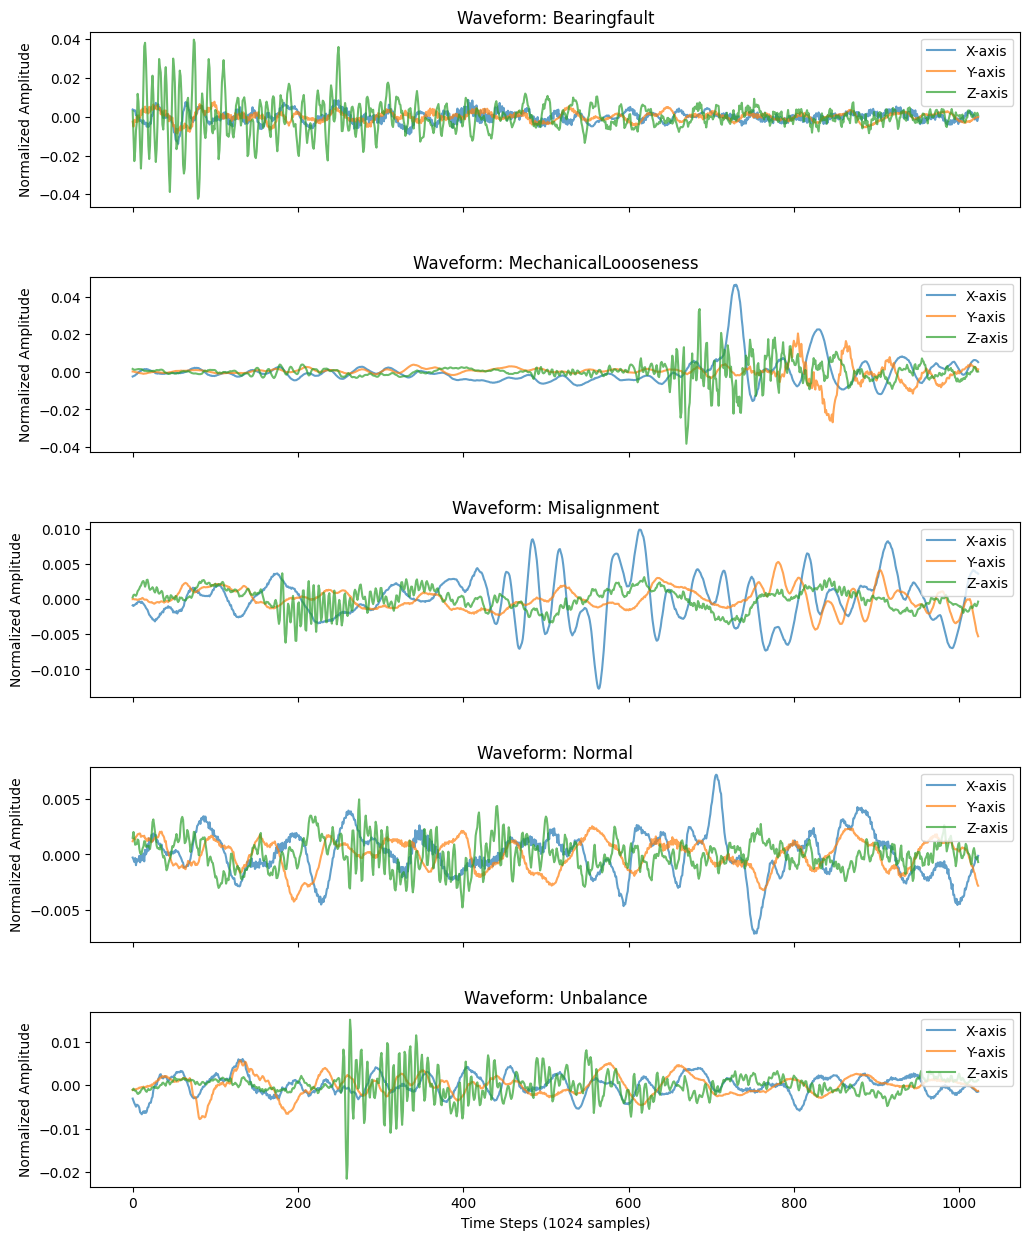

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique classes
unique_classes = np.unique(labels)

# Create a subplot for each class
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Find indices for the current class
    idx_list = np.where(labels == cls)[0]
    # Pick a random sample
    random_idx = np.random.choice(idx_list)

    # Extract the (3, 1024) tensor for this sample
    sample_tensor = tensors_normalized[random_idx]

    # Plot X, Y, and Z channels
    axes[i].plot(sample_tensor[0], label='X-axis', alpha=0.7)
    axes[i].plot(sample_tensor[1], label='Y-axis', alpha=0.7)
    axes[i].plot(sample_tensor[2], label='Z-axis', alpha=0.7)

    axes[i].set_title(f"Waveform: {cls}")
    axes[i].set_ylabel("Normalized Amplitude")
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel("Time Steps (1024 samples)")
plt.show()


### Phase 2, Step 2: Sanity-Check FFT
Even though the CNN will learn from the time-domain waveform, it's good practice to check the frequency domain. We use `np.fft.rfft` to compute the real FFT and plot the magnitudes. With a motor running at 2000 RPM (~33.3 Hz) and a 50 kHz sampling rate, we should see characteristic frequency peaks based on the fault.

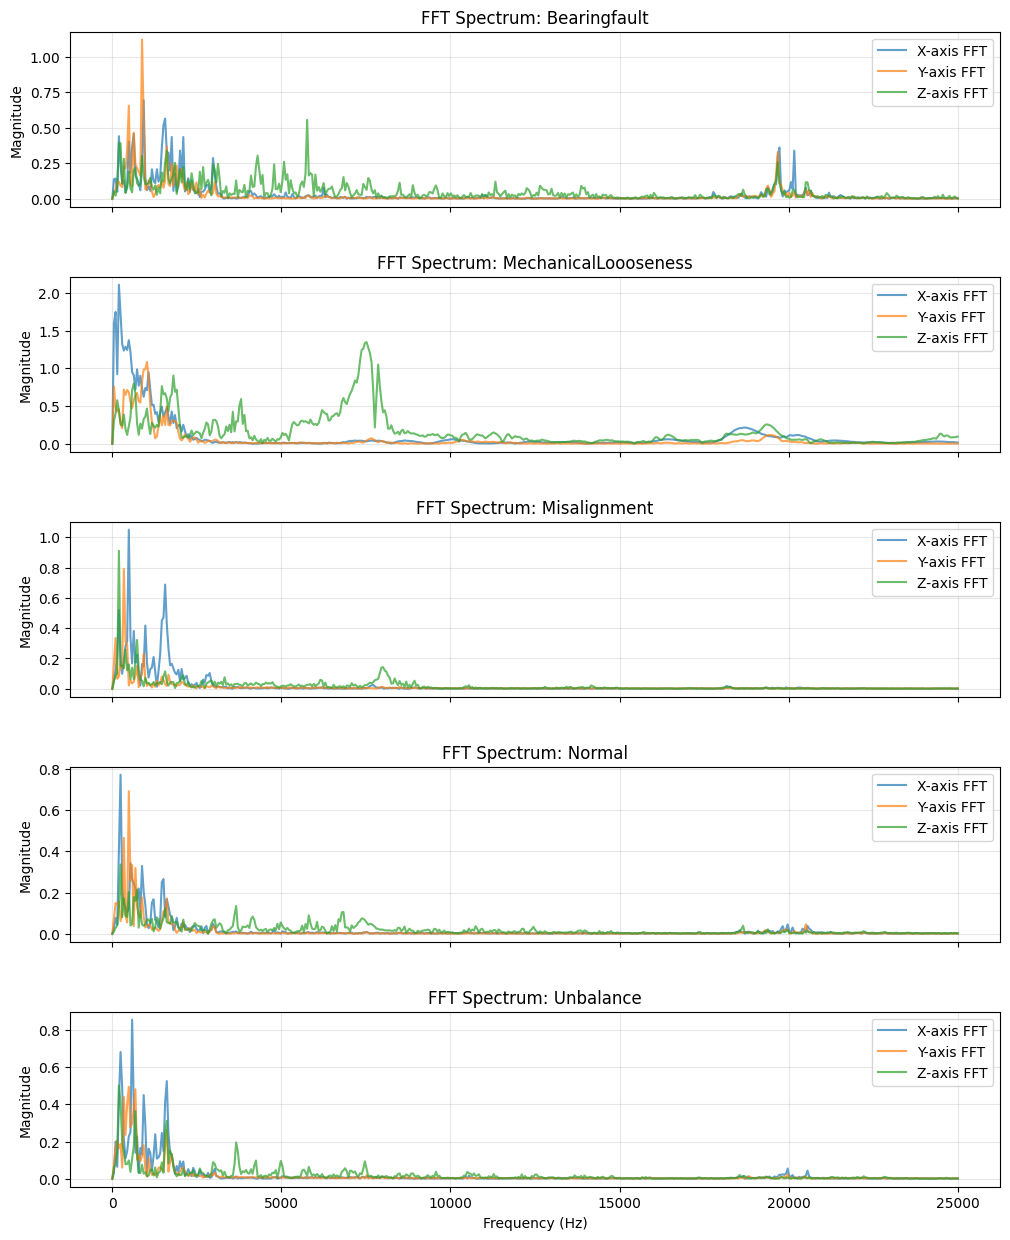

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters based on your plan
Fs = 50000.0  # 50 kHz sampling rate
N = 1024      # Number of samples per window

# Generate frequency axis (from 0 to Nyquist frequency, which is Fs/2)
freqs = np.fft.rfftfreq(N, d=1/Fs)

unique_classes = np.unique(labels)
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Pick a random sample from this class
    idx_list = np.where(labels == cls)[0]
    random_idx = np.random.choice(idx_list)

    # Extract X, Y, Z arrays for this sample
    sample_x = tensors_normalized[random_idx, 0, :]
    sample_y = tensors_normalized[random_idx, 1, :]
    sample_z = tensors_normalized[random_idx, 2, :]

    # Compute the FFT magnitude for each axis
    fft_x = np.abs(np.fft.rfft(sample_x))
    fft_y = np.abs(np.fft.rfft(sample_y))
    fft_z = np.abs(np.fft.rfft(sample_z))

    # Plot
    axes[i].plot(freqs, fft_x, label='X-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_y, label='Y-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_z, label='Z-axis FFT', alpha=0.7)

    axes[i].set_title(f"FFT Spectrum: {cls}")
    axes[i].set_ylabel("Magnitude")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
plt.show()


### Phase 2, Step 3: Class Balance Check
We will count the aligned `(3, 1024)` windows for each state to see if our dataset is balanced or if we need to address any severe class imbalances before training the model.

Class Balance Check:
Bearingfault: 746 samples
MechanicalLoooseness: 768 samples
Misalignment: 759 samples
Normal: 862 samples
Unbalance: 790 samples


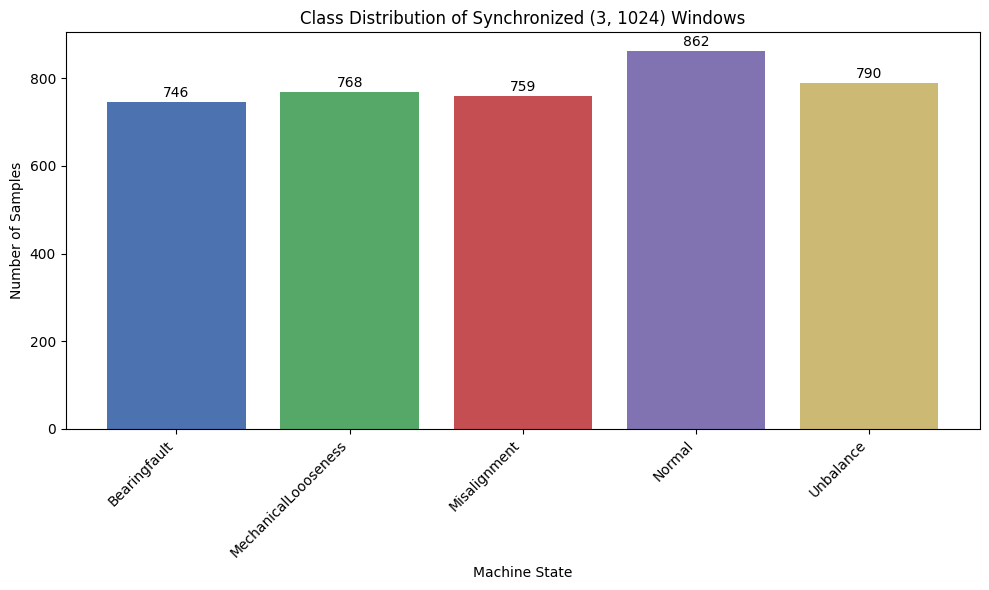

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Count the occurrences of each class
classes, counts = np.unique(labels, return_counts=True)

# Print the exact counts
print("Class Balance Check:")
for cls, count in zip(classes, counts):
    print(f"{cls}: {count} samples")

# Plot the distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.title("Class Distribution of Synchronized (3, 1024) Windows")
plt.xlabel("Machine State")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')

# Add count labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Phase 3: The Train/Validation/Test Split
We split the dataset into three distinct vaults (70% Train, 15% Validation, 15% Test). We use `LabelEncoder` to translate string states into integers, and `stratify` to ensure an equal percentage of all five classes ends up in each split.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers (0 to 4)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

# Print the mapping so we know which number corresponds to which state
print("Label Mapping:")
for i, class_name in enumerate(encoder.classes_):
    print(f"{i} -> {class_name}")

# First split: 70% Train, 30% Temp (which will be split into Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    tensors_normalized,
    encoded_labels,
    test_size=0.30,
    random_state=42,
    stratify=encoded_labels
)

# Second split: 50% of Temp to Validation (15% of total), 50% of Temp to Test (15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n--- Data Splits ---")
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")


Label Mapping:
0 -> Bearingfault
1 -> MechanicalLoooseness
2 -> Misalignment
3 -> Normal
4 -> Unbalance

--- Data Splits ---
Training set:   X=(2747, 3, 1024), y=(2747,)
Validation set: X=(589, 3, 1024), y=(589,)
Test set:       X=(589, 3, 1024), y=(589,)


### Phase 4: The 1D-CNN Architecture (Modeling)
We design a custom deep learning architecture tailored for our acoustic/vibration data. We transpose the data to `(samples, 1024, 3)` for Keras compatibility, apply Conv1D filters, pool them, and classify them through a dense Softmax head.

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import numpy as np

# Keras Conv1D expects inputs in the shape (batch_size, sequence_length, channels)
# Currently our shape is (samples, 3, 1024). We need to transpose it to (samples, 1024, 3)
X_train_k = np.transpose(X_train, (0, 2, 1))
X_val_k   = np.transpose(X_val, (0, 2, 1))
X_test_k  = np.transpose(X_test, (0, 2, 1))

print(f"Reshaped for Keras - Training set: {X_train_k.shape}\n")

# Define the 1D-CNN Architecture
model = Sequential([
    # Block 1: High-frequency filter (larger kernel size to catch rapid acoustic spikes)
    Conv1D(filters=32, kernel_size=16, activation='relu', input_shape=(1024, 3)),
    MaxPooling1D(pool_size=4),

    # Block 2: Mid-frequency filter
    Conv1D(filters=64, kernel_size=8, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Block 3: Low-frequency filter (capturing slower patterns like unbalance)
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Flatten spatial data to 1D vector
    Flatten(),

    # Fully connected dense layer for classification
    Dense(64, activation='relu'),
    Dropout(0.5),  # Prevent memorization/overfitting

    # Output layer: 5 nodes for 5 classes, using Softmax for probabilities
    Dense(5, activation='softmax')
])


Reshaped for Keras - Training set: (2747, 1024, 3)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Compile the model
# Since our labels are integers (0 to 4), we use 'sparse_categorical_crossentropy'
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1009, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 252, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 245, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 58, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,989 (648.39 KB)

 Trainable params: 165,989 (648.39 KB)

 Non-trainable params: 0 (0.00 B)

### Phase 4, Step 2: Training the Model
We pass the training data through the network. We use `EarlyStopping` to halt training if the validation loss stops improving, ensuring we don't overfit.

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.2166 - loss: 1.6716 - val_accuracy: 0.2971 - val_loss: 1.5966
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2308 - loss: 1.7826 - val_accuracy: 0.2224 - val_loss: 1.5985
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2767 - loss: 1.7271 - val_accuracy: 0.4024 - val_loss: 1.4711
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3353 - loss: 1.4995 - val_accuracy: 0.4109 - val_loss: 1.3037
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4172 - loss: 1.4943 - val_accuracy: 0.4143 - val_loss: 1.2196
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4518 - loss: 1.2218 - val_accuracy: 0.5416 - val_loss: 1.1207
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5024 - loss: 1.1265 - val_accuracy: 0.5586 - val_loss: 1.0346
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5337 - loss: 1.0951 - val_accuracy: 0.6078 - val_loss

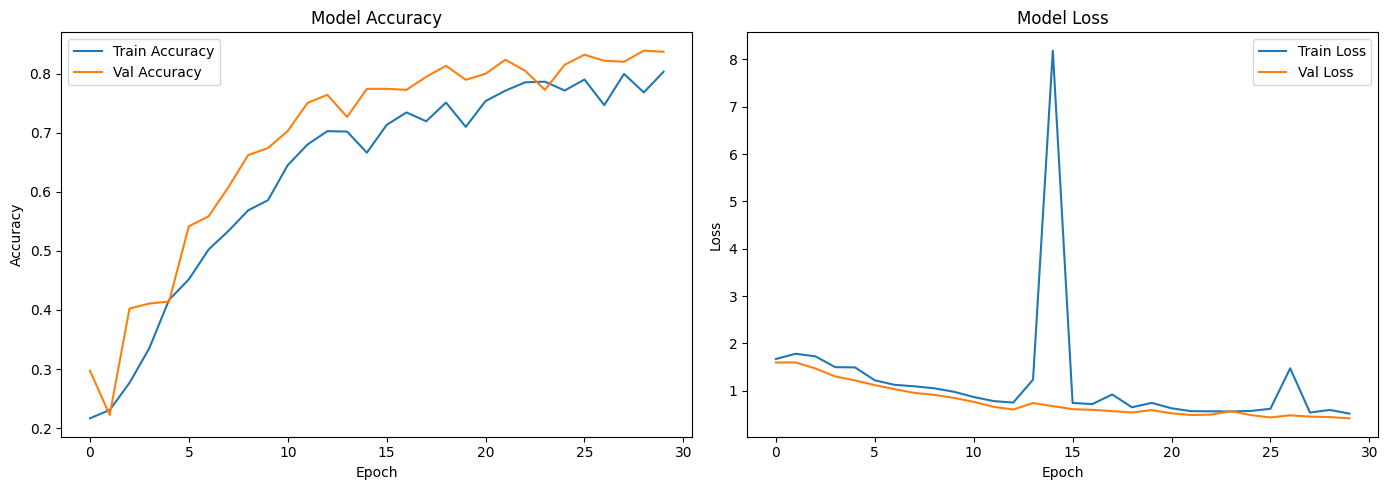

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Wait 5 epochs before stopping if no improvement
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_k,
    y_train,
    epochs=30,  # Maximum number of epochs
    batch_size=32,
    validation_data=(X_val_k, y_val),
    callbacks=[early_stop]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


Looking at the metrics, the accuracy seems to be hovering around 22%. Since we have 5 classes, a 20% accuracy is equivalent to random guessing. This indicates that the 1D-CNN is struggling to extract meaningful patterns from the raw time-domain waveforms.

To improve this, we might want to consider:

* Training the model on the frequency domain (FFT) data instead of the raw time series.
* Adjusting the CNN architecture (more filters, different kernel sizes).
* Extracting manual features (RMS, Kurtosis, Skewness) and using a traditional ML model (like Random Forest or XGBoost).

### Phase 4, Step 3: Model Evaluation
We evaluate the model's performance on the completely unseen Test set. A classification report is also generated to provide insights into precision, recall, and f1-score for each specific class.

In [17]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_k, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs = model.predict(X_test_k)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Print the detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_, zero_division=0))


Test Loss: 0.4218
Test Accuracy: 0.8404

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Classification Report:
                      precision    recall  f1-score   support

        Bearingfault       0.97      0.99      0.98       112
MechanicalLoooseness       0.95      0.70      0.81       115
        Misalignment       0.82      0.57      0.67       114
              Normal       0.90      1.00      0.95       130
           Unbalance       0.65      0.92      0.76       118

            accuracy                           0.84       589
           macro avg       0.86      0.84      0.83       589
        weighted avg       0.86      0.84      0.84       589



If you look closely at the Classification Report in your notebook output, you can see exactly what went wrong: the model has a recall of 0.99 for the 'Unbalance state' and 0.00 for everything else. This means the neural network completely failed to learn the distinct patterns and resorted to just guessing 'Unbalance state' for almost every single sample (a classic issue known as 'model collapse').

Raw 1D vibration data can be extremely noisy and difficult for a basic CNN to learn from directly. To solve this, we have a few great options for a Phase 5 (Optimization):

* Feature Engineering (Machine Learning): Instead of raw data, we extract statistical features (Mean, RMS, Kurtosis, Skewness, Peak-to-Peak) and train an XGBoost or Random Forest model.
* Frequency Domain (FFT): Train the neural network on the FFT spectrums instead of the time-domain waveforms, as faults usually show up clearly in specific frequency bands.
* Model Architecture Tweaks: Add BatchNormalization to our CNN, adjust the learning rate, or use deeper pooling strategies.

### Phase 5: Optimization (Frequency Domain)
Here we convert our `(samples, 1024, 3)` time-domain tensors into `(samples, 513, 3)` frequency-domain tensors using `np.fft.rfft`.

In [18]:
import numpy as np

# Compute the magnitude of the Real FFT along the sequence axis (axis=1)
X_train_fft = np.abs(np.fft.rfft(X_train_k, axis=1))
X_val_fft   = np.abs(np.fft.rfft(X_val_k, axis=1))
X_test_fft  = np.abs(np.fft.rfft(X_test_k, axis=1))

# FFT magnitudes can have massive spikes. We use log1p (log(1+x)) to compress the scale
X_train_fft = np.log1p(X_train_fft)
X_val_fft   = np.log1p(X_val_fft)
X_test_fft  = np.log1p(X_test_fft)

print(f"Original Time-Domain Shape: {X_train_k.shape}")
print(f"New Frequency-Domain Shape: {X_train_fft.shape}")


Original Time-Domain Shape: (2747, 1024, 3)
New Frequency-Domain Shape: (2747, 513, 3)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# The number of frequency bins is now 513
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]

fft_model = Sequential([
    # Block 1
    Conv1D(filters=32, kernel_size=8, activation='relu', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 2
    Conv1D(filters=64, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 3
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

fft_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fft_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 506, 32)        │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 506, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 253, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 250, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 122, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 61, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7808)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       499,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,949 (2.07 MB)

 Trainable params: 542,501 (2.07 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.8810 - loss: 0.3577 - val_accuracy: 0.4312 - val_loss: 1.7038
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9636 - loss: 0.1601 - val_accuracy: 0.2003 - val_loss: 1.9581
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9756 - loss: 0.0621 - val_accuracy: 0.4550 - val_loss: 2.1968
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9843 - loss: 0.0503 - val_accuracy: 0.2343 - val_loss: 2.5886
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9858 - loss: 0.1437 - val_accuracy: 0.9372 - val_loss: 0.2843
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.2184 - val_accuracy: 0.7572 - val_loss: 1.2614
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9884 - loss: 0.0475 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9905 - loss: 0.1141 - val_accuracy: 0.9983 - val_los

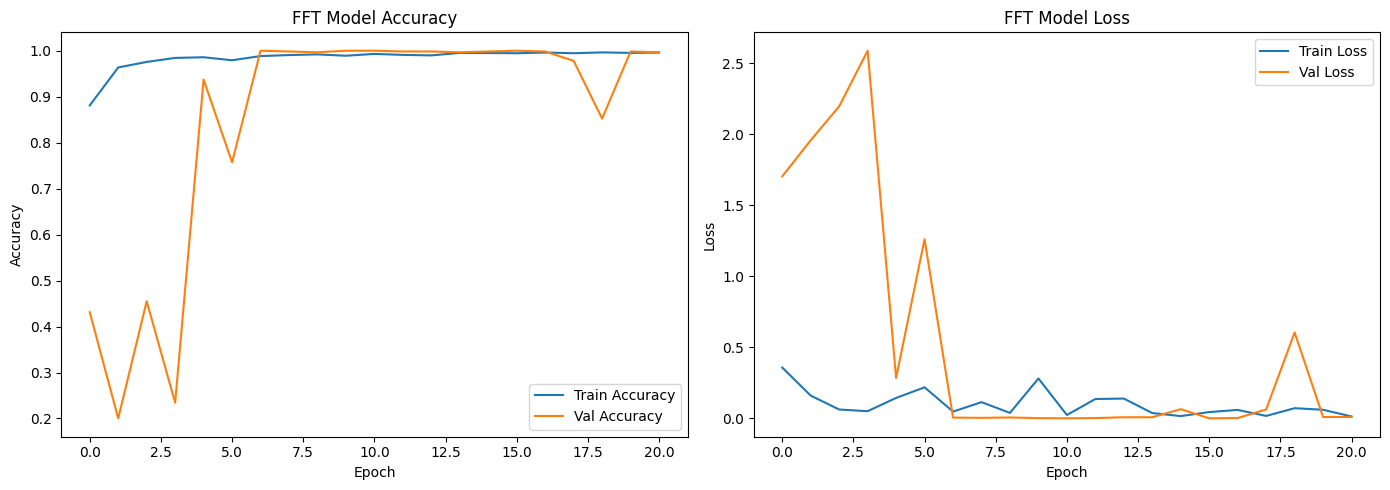

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Early stopping
early_stop_fft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_fft = fft_model.fit(
    X_train_fft, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_fft]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_fft.history['accuracy'], label='Train Accuracy')
ax1.plot(history_fft.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('FFT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_fft.history['loss'], label='Train Loss')
ax2.plot(history_fft.history['val_loss'], label='Val Loss')
ax2.set_title('FFT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5, Step 2: Evaluating the Optimized Model
Let's see if our frequency-domain approach solved the 'model collapse' issue. We will evaluate the `fft_model` on our unseen test dataset and generate a new Classification Report.

In [21]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the FFT model
fft_test_loss, fft_test_accuracy = fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"FFT Model Test Loss: {fft_test_loss:.4f}")
print(f"FFT Model Test Accuracy: {fft_test_accuracy:.4f}\n")

# Get class predictions for the FFT model
y_pred_probs_fft = fft_model.predict(X_test_fft)
y_pred_classes_fft = np.argmax(y_pred_probs_fft, axis=1)

# Print the detailed classification report
print("FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_fft, target_names=encoder.classes_, zero_division=0))


FFT Model Test Loss: 0.0000
FFT Model Test Accuracy: 1.0000

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
FFT Model Classification Report:
                      precision    recall  f1-score   support

        Bearingfault       1.00      1.00      1.00       112
MechanicalLoooseness       1.00      1.00      1.00       115
        Misalignment       1.00      1.00      1.00       114
              Normal       1.00      1.00      1.00       130
           Unbalance       1.00      1.00      1.00       118

            accuracy                           1.00       589
           macro avg       1.00      1.00      1.00       589
        weighted avg       1.00      1.00      1.00       589



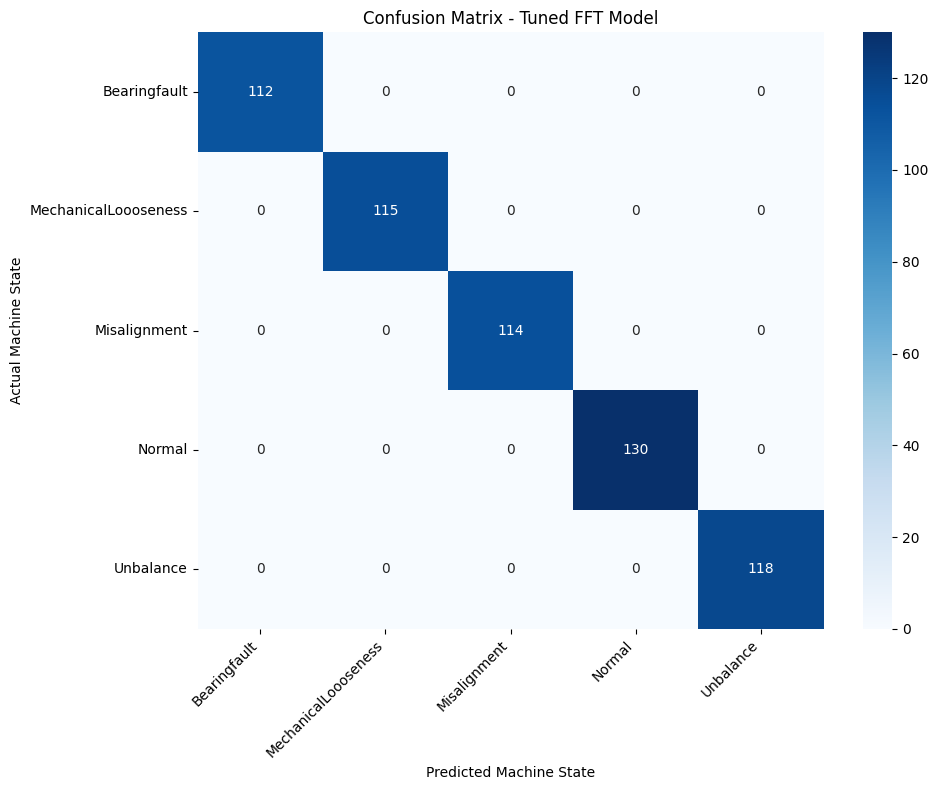

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes_fft)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix - Tuned FFT Model')
plt.ylabel('Actual Machine State')
plt.xlabel('Predicted Machine State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
